# Smart Workout Week 1 Complete Notebook

Final-product-ready notebook for **Earth and Non** Week 1 tasks in `TODO.md`.

This version is designed to be both an analysis notebook and a project handoff artifact. It includes raw inspection, cleaning evidence, validation tables, outlier proof, silhouette-score comparison, cluster profile tables, descriptive analytics plots, and final output manifests.

## Final product purpose

- Clean and validate all four raw datasets.
- Create processed CSV files that can be used by backend services and Week 2 ML.
- Create dashboard-ready summary tables and PNG figures.
- Document every Week 1 data decision with visible evidence.
- Produce a final checklist that maps outputs back to `TODO.md`.
        


## Week 1 TODO Coverage

| TODO.md line | Requirement | Evidence produced in this notebook |
|---|---|---|
| 691 | Load and inspect all 4 CSVs | Raw file audit, raw inspection summary, dtypes, missing values, duplicate counts |
| 692 | Clean Sleep dataset | Blood pressure split proof, BMI normalization proof, cleaned readiness table |
| 693 | Clean Gym Members dataset | Missing validation, BPM-response ratio, intensity band distribution |
| 694 | Clean ExerciseDB | Parsed list fields, parse proof table, coverage tables |
| 695 | Clean Nutrition dataset | Repair parser proof, numeric macro validation, macro summary |
| 696 | Derive Training Readiness | Readiness scoring table and readiness distribution |
| 697 | Outlier check on Calories_Burned | 3-sigma threshold table, outlier rows, capped calorie field |
| 700 | K-Means clustering | k=3 and k=4 silhouette table, selected k, cluster profile |
| 701 | Cross-dataset EDA | Workout, calorie, exercise coverage, nutrition, readiness, cluster plots |
| 702 | Save EDA plots as PNG | Figure manifest in `docs/figures/week1` |

The notebook also creates final-product handoff files for Week 2 ML, Week 3 dashboard, RAG/recommender work, and report writing.
        


## Cell 1: Imports and Display Settings

This cell loads the libraries used for data cleaning, validation, clustering, and plotting.

The code comments are aligned so that each important line explains its role directly.
        


In [1]:
from pathlib import Path                                                                                # Path objects keep Windows paths stable across raw, processed, notebook, and figure folders.
import ast                                                                                              # Safe parsing converts ExerciseDB string-list fields into real Python lists.
import csv                                                                                              # The nutrition file needs low-level CSV reading because some food names contain unquoted commas.
import json                                                                                             # JSON output stores manifests and dashboard-ready summary tables.
import re                                                                                               # Regular expressions standardize raw column names into snake_case.
import warnings                                                                                         # Warning control keeps notebook output focused on validation evidence.

from IPython.display import display                                                                     # Notebook display renders tables clearly in VSCode and Jupyter.
import matplotlib.pyplot as plt                                                                         # Matplotlib creates and saves static PNG figures for dashboard and report usage.
import numpy as np                                                                                      # NumPy supports vectorized scoring, thresholds, clipping, and numeric rules.
import pandas as pd                                                                                     # Pandas loads, cleans, validates, aggregates, and exports tabular datasets.
import seaborn as sns                                                                                   # Seaborn creates clean descriptive analytics plots with consistent styling.
from sklearn.cluster import KMeans                                                                      # K-Means creates sleep-based lifestyle archetypes.
from sklearn.metrics import silhouette_score                                                            # Silhouette score compares k=3 and k=4 cluster quality.
from sklearn.preprocessing import StandardScaler                                                        # StandardScaler prevents high-scale variables from dominating cluster distance.

warnings.filterwarnings("ignore", category=FutureWarning)                                               # Future warnings do not affect current Week 1 analysis results.
pd.set_option("display.max_columns", 120)                                                               # Wide table display keeps validation columns visible.
pd.set_option("display.width", 180)                                                                     # Wide text output improves readability in VSCode.
sns.set_theme(style="whitegrid", palette="Set2")                                                        # A consistent plot theme keeps Week 1 figures presentation-ready.


## Cell 2: Project Paths and Required File Contract

This cell defines the expected project root and output locations.

The notebook should be placed in:

```text
notebooks/week1/smart_workout_week1_complete_final_product.ipynb
```

It reads raw data from `data/raw`, writes cleaned files to `data/processed`, and saves figures to `docs/figures/week1`.
        


In [2]:
PROJECT_ROOT = Path.cwd()                                                                               # The current VSCode workspace is used when the notebook is opened from the project root.
DEFAULT_PROJECT_ROOT = Path(r"C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main")  # Fallback path matches the observed local Smart Workout project folder.

if not (PROJECT_ROOT / "data" / "raw").exists():                                                        # This guard handles execution from a notebook subfolder or copied output folder.
    PROJECT_ROOT = DEFAULT_PROJECT_ROOT                                                                 # The fallback keeps the notebook runnable when the working directory is not the repo root.

RAW_DIR = PROJECT_ROOT / "data" / "raw"                                                                 # Raw CSV files remain unchanged in this folder.
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"                                                     # Cleaned CSV files are exported here for backend and ML usage.
FIGURES_DIR = PROJECT_ROOT / "docs" / "figures" / "week1"                                               # EDA PNG figures are exported here for dashboard and report reuse.
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "week1"                                                     # This folder is the recommended final location for the notebook.

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)                                                        # The processed-data output folder is created when missing.
FIGURES_DIR.mkdir(parents=True, exist_ok=True)                                                          # The Week 1 figure-output folder is created when missing.
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)                                                         # The recommended notebook folder is created when missing.

RAW_FILES = {                                                                                           # The required raw dataset filenames are stored in one contract dictionary.
    "sleep": "Sleep_health_and_lifestyle_dataset.csv",                                                  # Sleep dataset supports readiness and lifestyle clustering.
    "gym": "gym_members_exercise_tracking.csv",                                                         # Gym dataset supports calorie and intensity modeling.
    "exercise": "exercisedb_all_raw_flat.csv",                                                          # ExerciseDB supports recommendation and RAG instructions.
    "nutrition": "daily_food_nutrition_dataset.csv",                                                    # Nutrition dataset supports macro dashboard context.
}                                                                                                       # End of raw-file contract.

print('Project root:', PROJECT_ROOT)                                                                    # The selected project root is printed for reproducibility.
print('Raw folder:', RAW_DIR)                                                                           # The raw data folder is printed before file loading.
print('Processed folder:', PROCESSED_DIR)                                                               # The processed output folder is printed before exports.
print('Figures folder:', FIGURES_DIR)                                                                   # The figure output folder is printed before plot saving.

assert RAW_DIR.exists(), f'Missing raw data folder: {RAW_DIR}'                                          # The notebook stops early if the raw data folder is unavailable.


Project root: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main
Raw folder: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\raw
Processed folder: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed
Figures folder: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\docs\figures\week1


## Cell 3: Raw File Audit Table

This table proves that the four required datasets exist before cleaning begins.

Why this matters:

- Missing files should fail early.
- File size helps detect incomplete downloads.
- The audit table supports the Week 1 report narrative.
        


In [3]:
file_audit_rows = []                                                                                    # Each row stores one raw-file availability check.

for dataset_name, filename in RAW_FILES.items():                                                        # Each required dataset is checked from the central contract.
    file_path = RAW_DIR / filename                                                                      # The full path is built from the raw folder and filename.
    file_audit_rows.append({                                                                            # One audit dictionary is appended per dataset.
        "dataset": dataset_name,                                                                        # Dataset role name.
        "filename": filename,                                                                           # Exact raw filename expected by the notebook.
        "exists": file_path.exists(),                                                                   # Boolean file existence result.
        "size_kb": round(file_path.stat().st_size / 1024, 2) if file_path.exists() else 0,              # File size helps detect empty or partial files.
        "path": str(file_path),                                                                         # Full path documents the source location.
    })                                                                                                  # End of one audit record.

file_audit = pd.DataFrame(file_audit_rows)                                                              # The audit list becomes a readable validation table.
display(file_audit)                                                                                     # The table is displayed before any data transformation.

missing_raw_files = file_audit.loc[~file_audit["exists"], "filename"].tolist()                          # Missing filenames are isolated for a clear failure message.
assert not missing_raw_files, f'Missing required raw files: {missing_raw_files}'                        # All four datasets are required for Week 1 completion.


,dataset,filename,exists,size_kb,path
0,sleep,Sleep_health_and_lifestyle_dataset.csv,True,23.21,C:\Users\Waranon-021\Desktop\BIA Project\12597...
1,gym,gym_members_exercise_tracking.csv,True,63.61,C:\Users\Waranon-021\Desktop\BIA Project\12597...
2,exercise,exercisedb_all_raw_flat.csv,True,990.17,C:\Users\Waranon-021\Desktop\BIA Project\12597...
3,nutrition,daily_food_nutrition_dataset.csv,True,46.41,C:\Users\Waranon-021\Desktop\BIA Project\12597...


## Cell 4: Helper Functions for Inspection, Cleaning, Export, and Plot Saving

These helpers keep the notebook consistent.

They also make the final output easier to audit because every dataset follows the same inspection and export pattern.
        


In [4]:
def clean_column_name(name: str) -> str:                                                                # Raw column names are converted into Python-friendly snake_case names.
    name = re.sub(r"(?<=[a-z0-9])(?=[A-Z])", "_", str(name))                                            # camelCase names such as bodyParts become body_Parts before final cleanup.
    name = re.sub(r"[^0-9a-zA-Z]+", "_", name)                                                          # Spaces, parentheses, slashes, and symbols become underscores.
    return name.strip("_").lower()                                                                      # Lowercase snake_case prevents later feature-engineering mistakes.

def standardize_columns(df: pd.DataFrame) -> pd.DataFrame:                                              # A dataframe copy is returned with standardized column names.
    cleaned = df.copy()                                                                                 # The raw dataframe remains unchanged for proof tables.
    cleaned.columns = [clean_column_name(column) for column in cleaned.columns]                         # Every column follows the same naming rule.
    return cleaned                                                                                      # The standardized dataframe is returned for cleaning steps.

def dataset_inspection(df: pd.DataFrame, name: str) -> dict:                                            # Core inspection metrics are collected for one dataframe.
    return {                                                                                            # The dictionary becomes one row in the raw inspection summary.
        "dataset": name,                                                                                # Dataset display name.
        "rows": int(df.shape[0]),                                                                       # Number of records.
        "columns": int(df.shape[1]),                                                                    # Number of fields.
        "total_missing": int(df.isna().sum().sum()),                                                    # Total missing cells across the dataset.
        "duplicate_rows": int(df.duplicated().sum()),                                                   # Exact duplicate row count.
        "memory_mb": round(df.memory_usage(deep=True).sum() / (1024 ** 2), 3),                          # Approximate in-memory size for documentation.
    }                                                                                                   # End of inspection dictionary.

def show_raw_inspection(df: pd.DataFrame, name: str, preview_rows: int = 5) -> dict:                    # Detailed inspection tables are displayed for one raw dataframe.
    summary = dataset_inspection(df, name)                                                              # The compact inspection summary is created first.
    print(f'=== {name}: SUMMARY ===')                                                                   # A visible section title keeps notebook output organized.
    display(pd.DataFrame([summary]))                                                                    # The compact summary is displayed as a table.
    print(f'=== {name}: DTYPES ===')                                                                    # Column dtype evidence is shown before cleaning.
    display(pd.DataFrame({"column": df.columns, "dtype": df.dtypes.astype(str).values}))                # Dtype table reveals numeric fields loaded as text.
    print(f'=== {name}: MISSING VALUES ===')                                                            # Missing-value evidence is shown before cleaning.
    display(df.isna().sum().sort_values(ascending=False).to_frame("missing_count"))                     # Sorted missing counts highlight the biggest cleaning issues.
    print(f'=== {name}: FIRST ROWS ===')                                                                # First rows show headers, units, and visible raw structure.
    display(df.head(preview_rows))                                                                      # Preview rows help verify file parsing.
    print(f'=== {name}: LAST ROWS ===')                                                                 # Last rows reveal footer notes or trailing irregular records.
    display(df.tail(preview_rows))                                                                      # Tail preview helps confirm file ending quality.
    return summary                                                                                      # The summary is returned for the final raw inspection table.

def parse_string_list(value) -> list[str]:                                                              # ExerciseDB string-list fields are converted into normalized lists.
    if pd.isna(value):                                                                                  # Missing values become empty lists instead of text nan values.
        return []                                                                                       # Empty lists are easier to filter and explode later.
    if isinstance(value, list):                                                                         # Already parsed lists can appear after rerunning cells.
        return [str(item).strip().lower() for item in value if str(item).strip()]                       # Existing list items are normalized.
    try:                                                                                                # Safe parsing is attempted first.
        parsed = ast.literal_eval(str(value))                                                           # literal_eval parses strings such as ['back'] without executing arbitrary code.
    except (SyntaxError, ValueError):                                                                   # Malformed values are preserved instead of stopping the notebook.
        parsed = [value]                                                                                # The raw value becomes one list item for later review.
    if isinstance(parsed, list):                                                                        # Parsed lists are normalized item by item.
        return [str(item).strip().lower() for item in parsed if str(item).strip()]                      # Whitespace and capitalization are cleaned.
    return [str(parsed).strip().lower()] if str(parsed).strip() else []                                 # Scalar parsed values are wrapped as a list.

def count_list_values(series: pd.Series) -> pd.Series:                                                  # List-column category values are counted after exploding.
    return series.explode().dropna().value_counts()                                                     # Exploding turns each list item into a separate countable row.

def export_dataframe(df: pd.DataFrame, filename: str) -> Path:                                          # Processed tables are saved in data/processed.
    output_path = PROCESSED_DIR / filename                                                              # The output path is created from the shared processed folder.
    df.to_csv(output_path, index=False, encoding="utf-8")                                               # CSV export excludes artificial notebook indexes.
    print(f'Saved processed file: {output_path}')                                                       # The exact saved path is printed for traceability.
    return output_path                                                                                  # The path is returned for manifest construction.

def save_current_plot(filename: str) -> Path:                                                           # Active matplotlib figures are saved as Week 1 PNG assets.
    output_path = FIGURES_DIR / filename                                                                # All plots are stored under docs/figures/week1.
    plt.tight_layout()                                                                                  # Layout tightening reduces clipped labels.
    plt.savefig(output_path, dpi=160, bbox_inches="tight")                                              # 160 DPI is clear enough for dashboard, report, and slide usage.
    plt.show()                                                                                          # The plot is rendered inside the notebook for visual review.
    plt.close()                                                                                         # The figure is closed to avoid overlap with later plots.
    return output_path                                                                                  # The saved path is returned for figure manifest construction.


## Cell 5: Load Raw Datasets and Build Raw Inspection Summary

This cell loads all four datasets and produces raw inspection evidence.

For nutrition, a repair-aware loader is introduced because the raw file contains unquoted commas inside several `Food_Item` values.
        


In [5]:
sleep_raw = pd.read_csv(RAW_DIR / RAW_FILES['sleep'])                                                   # Sleep CSV loads directly with pandas.
gym_raw = pd.read_csv(RAW_DIR / RAW_FILES['gym'])                                                       # Gym tracking CSV loads directly with pandas.
exercise_raw = pd.read_csv(RAW_DIR / RAW_FILES['exercise'])                                             # ExerciseDB CSV loads directly, but list-like fields still need parsing.

nutrition_path = RAW_DIR / RAW_FILES['nutrition']                                                       # Nutrition path is stored because the file needs repair-aware parsing.
nutrition_default_error = None                                                                          # The default parser error is stored for data-quality proof.
try:                                                                                                    # A default pandas read is attempted to document the parsing issue.
    nutrition_default_attempt = pd.read_csv(nutrition_path)                                             # This may fail because of unquoted commas inside food names.
except Exception as error:                                                                              # Parser failure is captured instead of stopping the notebook.
    nutrition_default_error = f'{type(error).__name__}: {error}'                                        # The error message becomes evidence for the cleaning section.

def load_nutrition_csv_repaired(path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:                       # The nutrition loader repairs rows with extra comma splits in Food_Item.
    with path.open("r", encoding="utf-8-sig", newline="") as handle:                                    # BOM-safe UTF-8 keeps the header clean.
        reader = csv.reader(handle)                                                                     # csv.reader exposes raw row field counts.
        header = next(reader)                                                                           # The header defines the expected logical field count.
        expected_count = len(header)                                                                    # Expected count is used to detect malformed rows.
        repaired_rows = []                                                                              # Repaired logical rows are collected here.
        repair_log = []                                                                                 # Repair evidence is collected row by row.
        for line_number, row in enumerate(reader, start=2):                                             # Line numbers start at 2 because line 1 is the header.
            raw_count = len(row)                                                                        # Raw field count shows whether the row structure is valid.
            if raw_count == expected_count:                                                             # Rows with the expected count are already valid.
                fixed_row = row                                                                         # The original row is preserved.
                repair_action = 'no_repair_needed'                                                      # Repair log records that no change was needed.
            elif raw_count > expected_count:                                                            # Extra fields usually indicate commas inside Food_Item.
                extra_fields = raw_count - expected_count                                               # The number of extra fields tells how many initial fragments to rejoin.
                fixed_food_item = ','.join(row[: extra_fields + 1])                                     # Food item fragments are joined back together.
                fixed_row = [fixed_food_item] + row[extra_fields + 1 :]                                 # The repaired food item is combined with the remaining columns.
                repair_action = 'food_item_comma_repaired'                                              # Repair log records an actual row repair.
            else:                                                                                       # Short rows are padded to preserve rectangular structure.
                fixed_row = row + [''] * (expected_count - raw_count)                                   # Blank values preserve missing trailing fields.
                repair_action = 'short_row_padded'                                                      # Repair log records a short-row issue.
            repaired_rows.append(fixed_row)                                                             # The repaired row is stored for dataframe creation.
            repair_log.append({                                                                         # A row-level repair record is stored for validation proof.
                'line_number': line_number,                                                             # Original CSV line number.
                'raw_field_count': raw_count,                                                           # Number of raw fields before repair.
                'expected_field_count': expected_count,                                                 # Expected logical column count.
                'repair_action': repair_action,                                                         # Repair action taken for this row.
                'food_item_after_repair': fixed_row[0],                                                 # Food item after possible repair.
            })                                                                                          # End of one repair-log record.
    return pd.DataFrame(repaired_rows, columns=header), pd.DataFrame(repair_log)                        # The repaired dataframe and proof log are returned.

nutrition_raw, nutrition_repair_log = load_nutrition_csv_repaired(nutrition_path)                       # Nutrition data is loaded with the repair-aware parser.

raw_summaries = []                                                                                      # Raw inspection summaries are collected across all four datasets.
raw_summaries.append(show_raw_inspection(sleep_raw, 'Sleep Health Raw'))                                # Sleep raw structure is inspected.
raw_summaries.append(show_raw_inspection(gym_raw, 'Gym Members Raw'))                                   # Gym raw structure is inspected.
raw_summaries.append(show_raw_inspection(exercise_raw, 'ExerciseDB Raw'))                               # ExerciseDB raw structure is inspected.
raw_summaries.append(show_raw_inspection(nutrition_raw, 'Nutrition Raw Repaired'))                      # Repaired nutrition raw structure is inspected.

raw_inspection_summary = pd.DataFrame(raw_summaries)                                                    # All raw inspection summaries are combined into one table.
display(raw_inspection_summary)                                                                         # The combined raw inspection table directly satisfies TODO raw inspection evidence.

raw_inspection_output = export_dataframe(raw_inspection_summary, 'week1_raw_inspection_summary.csv')    # Raw inspection summary is exported for report evidence.


=== Sleep Health Raw: SUMMARY ===


,dataset,rows,columns,total_missing,duplicate_rows,memory_mb
0,Sleep Health Raw,374,13,219,0,0.118


=== Sleep Health Raw: DTYPES ===


,column,dtype
0,Person ID,int64
1,Gender,object
2,Age,int64
3,Occupation,object
4,Sleep Duration,float64
5,Quality of Sleep,int64
6,Physical Activity Level,int64
7,Stress Level,int64
8,BMI Category,object
9,Blood Pressure,object


=== Sleep Health Raw: MISSING VALUES ===


...

,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
0,Scrambled Eggs (2 large),Protein/Dairy,180,12.0,2.0,14.0,0.0,1.0,180,370,Breakfast,250
1,Whole Wheat Toast (1 slice),Grain,80,4.0,14.0,1.0,2.0,2.0,140,0,Breakfast,0
2,Coffee (black),Beverage,5,0.3,0.0,0.1,0.0,0.0,5,0,Breakfast,0
3,Banana,Fruit,105,1.3,27.0,0.4,3.1,14.0,1,0,Breakfast,0
4,Grilled Chicken Salad,Meal/Protein,350,30.0,10.0,20.0,5.0,4.0,400,80,Lunch,500


=== Nutrition Raw Repaired: LAST ROWS ===


,Food_Item,Category,Calories (kcal),Protein (g),Carbohydrates (g),Fat (g),Fiber (g),Sugars (g),Sodium (mg),Cholesterol (mg),Meal_Type,Water_Intake (ml)
646,Pickled Cucumber (1/4 cup),Vegetable,10,0.5,2.0,0.0,1.0,1.0,300,0,Dinner,0
647,Fattoush Salad (1.5 cups),Meal/Vegetarian,250,5.0,25.0,15.0,6.0,5.0,500,0,Lunch,0
648,Fried Pita (1/2 pita in salad),Grain,80,2.0,12.0,3.0,1.0,0.5,150,0,Lunch,0
649,Sumac (1/2 tsp dressing),Condiment,5,0.1,1.0,0.2,0.5,0.0,1,0,Lunch,0
650,Pomegranate Molasses (1 tsp),Condiment,15,0.0,4.0,0.0,0.0,4.0,0,0,Lunch,0


,dataset,rows,columns,total_missing,duplicate_rows,memory_mb
0,Sleep Health Raw,374,13,219,0,0.118
1,Gym Members Raw,973,15,0,0,0.197
2,ExerciseDB Raw,1500,8,0,0,1.512
3,Nutrition Raw Repaired,651,12,0,54,0.403


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\week1_raw_inspection_summary.csv


## Cell 6: Nutrition Repair Proof Table

This cell proves that the nutrition parser repaired real CSV issues rather than applying unnecessary transformation.

Expected evidence:

- Default parser error if present.
- Field-count distribution.
- Rows with `food_item_comma_repaired`.
        


In [6]:
print('Default nutrition parser error:', nutrition_default_error)                                       # The default parser issue is documented when pandas cannot read the file normally.

nutrition_field_count_summary = nutrition_repair_log['raw_field_count'].value_counts().sort_index().reset_index() # Raw field-count distribution quantifies the CSV issue.
nutrition_field_count_summary.columns = ['raw_field_count', 'row_count']                                # Column names make the proof table readable.
display(nutrition_field_count_summary)                                                                  # Rows with more fields than expected indicate unquoted comma problems.

nutrition_repaired_rows = nutrition_repair_log[nutrition_repair_log['repair_action'] != 'no_repair_needed'].copy() # Only rows that needed repair are isolated for proof.
display(nutrition_repaired_rows.head(20))                                                               # Repaired examples show exactly which food names had comma issues.

nutrition_repair_summary_output = export_dataframe(nutrition_repair_log, 'nutrition_csv_repair_log.csv') # The full repair log is exported as final-product evidence.


Default nutrition parser error: ParserError: Error tokenizing data. C error: Expected 12 fields in line 21, saw 13



,raw_field_count,row_count
0,12,645
1,13,6


,line_number,raw_field_count,expected_field_count,repair_action,food_item_after_repair
19,21,13,12,food_item_comma_repaired,"Milk (2%, 1 cup)"
48,50,13,12,food_item_comma_repaired,"Tea (Green, 1 cup)"
233,235,13,12,food_item_comma_repaired,"Mustard (1 tbsp, yellow)"
236,238,13,12,food_item_comma_repaired,"Spinach (1 cup, raw)"
376,378,13,12,food_item_comma_repaired,"Margarita (1 drink, 4oz)"
443,445,13,12,food_item_comma_repaired,"Sugar (1 tsp, in broth)"


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\nutrition_csv_repair_log.csv


## Cell 7: Clean Sleep Data and Produce Cleaning Proof

This cell addresses:

- Blood pressure split into systolic and diastolic values.
- BMI category normalization.
- Missing `Sleep Disorder` cleanup.

The proof tables show before-and-after values instead of only saving a cleaned file.
        


In [7]:
sleep_clean = standardize_columns(sleep_raw)                                                            # Sleep columns are standardized before feature engineering.

sleep_bp_before = sleep_raw[['Blood Pressure']].head(12).copy()                                         # A before-table preserves the original combined blood pressure format.
bp_parts = sleep_clean['blood_pressure'].astype(str).str.extract(r'(?P<systolic_bp>\d+)\s*/\s*(?P<diastolic_bp>\d+)') # Regex captures both blood pressure numbers from values such as 126/83.
sleep_clean['systolic_bp'] = pd.to_numeric(bp_parts['systolic_bp'], errors='coerce')                    # Systolic blood pressure becomes numeric for safety rules.
sleep_clean['diastolic_bp'] = pd.to_numeric(bp_parts['diastolic_bp'], errors='coerce')                  # Diastolic blood pressure becomes numeric for safety rules.

sleep_clean['bmi_category_normalized'] = sleep_clean['bmi_category'].replace({'Normal Weight': 'Normal'}) # Normal Weight is merged into Normal to remove duplicate category meaning.
sleep_clean['sleep_disorder'] = sleep_clean['sleep_disorder'].fillna('None')                            # Missing disorder values become an explicit None category for descriptive analysis.

sleep_bp_after = sleep_clean[['blood_pressure', 'systolic_bp', 'diastolic_bp']].head(12).copy()         # The after-table proves that blood pressure was split correctly.
bmi_before_after = pd.DataFrame({                                                                       # BMI normalization proof compares raw and normalized category counts.
    'raw_bmi_count': sleep_clean['bmi_category'].value_counts(),                                        # Raw BMI category counts show the original labels.
    'normalized_bmi_count': sleep_clean['bmi_category_normalized'].value_counts(),                      # Normalized counts show the merged category result.
}).fillna(0).astype(int)                                                                                # Missing count combinations become zero for a clean proof table.

sleep_cleaning_proof = pd.DataFrame({                                                                   # Critical cleaning fields are checked for missing values after transformation.
    'field': ['systolic_bp', 'diastolic_bp', 'bmi_category_normalized', 'sleep_disorder'],              # Fields required by readiness and safety logic.
    'missing_after_cleaning': [                                                                         # Missing values are counted after cleaning.
        sleep_clean['systolic_bp'].isna().sum(),                                                        # Systolic missing count.
        sleep_clean['diastolic_bp'].isna().sum(),                                                       # Diastolic missing count.
        sleep_clean['bmi_category_normalized'].isna().sum(),                                            # BMI category missing count.
        sleep_clean['sleep_disorder'].isna().sum(),                                                     # Sleep disorder missing count after None fill.
    ],                                                                                                  # End of missing counts.
})                                                                                                      # End of sleep cleaning proof table.

display(sleep_bp_before)                                                                                # Original blood pressure values are displayed for before evidence.
display(sleep_bp_after)                                                                                 # Split blood pressure values are displayed for after evidence.
display(bmi_before_after)                                                                               # BMI normalization evidence is displayed.
display(sleep_cleaning_proof)                                                                           # Critical field validation evidence is displayed.

sleep_cleaning_proof_output = export_dataframe(sleep_cleaning_proof, 'sleep_cleaning_proof.csv')        # Sleep cleaning proof is exported for report evidence.


,Blood Pressure
0,126/83
1,125/80
2,125/80
3,140/90
4,140/90
5,140/90
6,140/90
7,120/80
8,120/80
9,120/80


,blood_pressure,systolic_bp,diastolic_bp
0,126/83,126,83
1,125/80,125,80
2,125/80,125,80
3,140/90,140,90
4,140/90,140,90
5,140/90,140,90
6,140/90,140,90
7,120/80,120,80
8,120/80,120,80
9,120/80,120,80


,raw_bmi_count,normalized_bmi_count
Normal,195,216
Normal Weight,21,0
Obese,10,10
Overweight,148,148


,field,missing_after_cleaning
0,systolic_bp,0
1,diastolic_bp,0
2,bmi_category_normalized,0
3,sleep_disorder,0


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\sleep_cleaning_proof.csv


## Cell 8: Derive Training Readiness Rule

This cell directly implements the TODO item:

```text
sleep quality + duration + stress + BMI -> Low/Mid/High band
```

Scoring rule:

- Sleep duration: 2 points if 7+ hours, 1 point if 6 to 6.99 hours, 0 otherwise.
- Sleep quality: 2 points if 8+, 1 point if 6 to 7, 0 otherwise.
- Stress: 2 points if 4 or lower, 1 point if 5 to 6, 0 otherwise.
- BMI: 2 points for Normal, 1 point for Overweight, 0 for Obese.

Band rule:

- Low: 0 to 3.
- Mid: 4 to 5.
- High: 6 to 8.
        


In [8]:
sleep_clean['sleep_duration_score'] = np.select(                                                        # Sleep duration is converted into a simple readiness contribution.
    [sleep_clean['sleep_duration'] >= 7.0, sleep_clean['sleep_duration'] >= 6.0],                       # Seven or more hours receives the strongest score.
    [2, 1],                                                                                             # Score values represent strong and partial readiness contribution.
    default=0,                                                                                          # Short sleep receives no duration contribution.
)                                                                                                       # End of sleep duration scoring.

sleep_clean['sleep_quality_score'] = np.select(                                                         # Sleep quality is converted into a readiness contribution.
    [sleep_clean['quality_of_sleep'] >= 8, sleep_clean['quality_of_sleep'] >= 6],                       # High and moderate quality thresholds are separated.
    [2, 1],                                                                                             # Score values represent strong and partial readiness contribution.
    default=0,                                                                                          # Poor sleep quality receives no quality contribution.
)                                                                                                       # End of sleep quality scoring.

sleep_clean['stress_score'] = np.select(                                                                # Stress is scored inversely because lower stress supports higher readiness.
    [sleep_clean['stress_level'] <= 4, sleep_clean['stress_level'] <= 6],                               # Low and moderate stress thresholds are separated.
    [2, 1],                                                                                             # Score values represent strong and partial readiness contribution.
    default=0,                                                                                          # High stress receives no stress contribution.
)                                                                                                       # End of stress scoring.

sleep_clean['bmi_score'] = sleep_clean['bmi_category_normalized'].str.lower().map({'normal': 2, 'overweight': 1, 'obese': 0}).fillna(1) # BMI category becomes a transparent readiness contribution.

sleep_clean['readiness_score'] = (                                                                      # The final readiness score is the sum of all component scores.
    sleep_clean['sleep_duration_score']                                                                 # Sleep duration component.
    + sleep_clean['sleep_quality_score']                                                                # Sleep quality component.
    + sleep_clean['stress_score']                                                                       # Stress component.
    + sleep_clean['bmi_score']                                                                          # BMI component.
)                                                                                                       # End of readiness score formula.

sleep_clean['readiness_band'] = np.select(                                                              # The numeric readiness score is converted into dashboard-friendly bands.
    [sleep_clean['readiness_score'] <= 3, sleep_clean['readiness_score'] <= 5],                         # Low and Mid thresholds are applied before High default.
    ['Low', 'Mid'],                                                                                     # Band labels match the TODO requirement.
    default='High',                                                                                     # Scores 6 to 8 become High readiness.
)                                                                                                       # End of readiness band assignment.

sleep_clean['elevated_bp_flag'] = (sleep_clean['systolic_bp'] >= 140) | (sleep_clean['diastolic_bp'] >= 90) # Elevated blood pressure is stored for later plan safety notes.
sleep_clean['high_heart_rate_flag'] = sleep_clean['heart_rate'] >= 90                                   # High resting heart rate is stored for later plan safety notes.

readiness_component_summary = sleep_clean.groupby('readiness_band')[                                    # Component averages explain why each band differs.
    ['sleep_duration_score', 'sleep_quality_score', 'stress_score', 'bmi_score', 'readiness_score']     # Component score columns are summarized by band.
].mean().round(2).reset_index()                                                                         # Rounded averages create a readable proof table.

readiness_distribution = sleep_clean['readiness_band'].value_counts().reindex(['Low', 'Mid', 'High']).rename_axis('readiness_band').reset_index(name='record_count') # Band counts prove that Low/Mid/High labels were created.

display(readiness_component_summary)                                                                    # Readiness score component proof is displayed.
display(readiness_distribution)                                                                         # Readiness band distribution is displayed.
display(sleep_clean[['sleep_duration', 'quality_of_sleep', 'stress_level', 'bmi_category_normalized', 'readiness_score', 'readiness_band']].head(15)) # Sample records verify the rule at row level.

readiness_component_output = export_dataframe(readiness_component_summary, 'readiness_component_summary.csv') # Readiness component proof is exported.
sleep_readiness_output = export_dataframe(sleep_clean, 'sleep_cleaned_readiness.csv')                   # Cleaned sleep readiness data is exported for downstream work.


,readiness_band,sleep_duration_score,sleep_quality_score,stress_score,bmi_score,readiness_score
0,High,2.00,1.85,1.54,1.82,7.21
1,Low,0.93,0.86,0.00,1.00,2.79
2,Mid,1.08,1.00,0.88,1.41,4.37


,readiness_band,record_count
0,Low,86
1,Mid,75
2,High,213


,sleep_duration,quality_of_sleep,stress_level,bmi_category_normalized,readiness_score,readiness_band
0,6.1,6,6,Overweight,4,Mid
1,6.2,6,8,Normal,4,Mid
2,6.2,6,8,Normal,4,Mid
3,5.9,4,8,Obese,0,Low
4,5.9,4,8,Obese,0,Low
5,5.9,4,8,Obese,0,Low
6,6.3,6,7,Obese,2,Low
7,7.8,7,6,Normal,6,High
8,7.8,7,6,Normal,6,High
9,7.8,7,6,Normal,6,High


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\readiness_component_summary.csv
Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\sleep_cleaned_readiness.csv


## Cell 9: Clean Gym Data, Build Intensity Target, and Prove Outlier Handling

This cell completes the gym-data TODO items:

- Verify missing values.
- Derive `bpm_response_ratio = Avg_BPM / Max_BPM`.
- Bin intensity into Low/Mid/High using the given thresholds.
- Check `Calories_Burned` outliers using 3-sigma.
- Create capped calorie values for safer modeling.
        


In [9]:
gym_clean = standardize_columns(gym_raw)                                                                # Gym columns are standardized before target engineering.

gym_missing_summary = gym_clean.isna().sum().rename_axis('column').reset_index(name='missing_count')    # Missing values are counted for every gym column.
display(gym_missing_summary)                                                                            # Missing-value proof satisfies the gym validation TODO item.

gym_clean['bpm_response_ratio'] = gym_clean['avg_bpm'] / gym_clean['max_bpm']                           # BPM response ratio measures average effort relative to maximum BPM.
gym_clean['intensity_band'] = pd.cut(                                                                   # The continuous BPM ratio is converted into a classification target.
    gym_clean['bpm_response_ratio'],                                                                    # The derived ratio is the input to the binning rule.
    bins=[-np.inf, 0.70, 0.85, np.inf],                                                                 # The thresholds come directly from TODO.md.
    labels=['Low', 'Mid', 'High'],                                                                      # Target labels match the final classification classes.
    include_lowest=True,                                                                                # The lowest values are included in the first bin.
)                                                                                                       # End of intensity band derivation.

gym_clean['calorie_burn_rate_kcal_per_hour'] = gym_clean['calories_burned'] / gym_clean['session_duration_hours'] # Calories per hour becomes the Week 2 regression target.

calorie_mean = gym_clean['calories_burned'].mean()                                                      # Mean is required for the 3-sigma outlier boundary.
calorie_std = gym_clean['calories_burned'].std()                                                        # Standard deviation defines expected calorie spread.
calorie_lower_bound = max(0, calorie_mean - 3 * calorie_std)                                            # The lower bound is clipped at zero because negative calories are impossible.
calorie_upper_bound = calorie_mean + 3 * calorie_std                                                    # The upper bound marks unusually high calorie burn values.
gym_clean['calories_burned_zscore'] = (gym_clean['calories_burned'] - calorie_mean) / calorie_std       # Z-score records distance from the mean for each session.
gym_clean['calorie_outlier_3sigma'] = gym_clean['calories_burned_zscore'].abs() > 3                     # Rows beyond three standard deviations are flagged.
gym_clean['calories_burned_clean'] = gym_clean['calories_burned'].clip(lower=calorie_lower_bound, upper=calorie_upper_bound) # Capping preserves row count while limiting extreme influence.

intensity_distribution = gym_clean['intensity_band'].value_counts().reindex(['Low', 'Mid', 'High']).rename_axis('intensity_band').reset_index(name='session_count') # Target-class counts validate the intensity label distribution.
outlier_proof = pd.DataFrame([{                                                                         # A one-row table documents the complete outlier rule.
    'calories_mean': round(calorie_mean, 2),                                                            # Mean used for 3-sigma calculation.
    'calories_std': round(calorie_std, 2),                                                              # Standard deviation used for 3-sigma calculation.
    'lower_bound_3sigma': round(calorie_lower_bound, 2),                                                # Lower outlier boundary.
    'upper_bound_3sigma': round(calorie_upper_bound, 2),                                                # Upper outlier boundary.
    'outlier_row_count': int(gym_clean['calorie_outlier_3sigma'].sum()),                                # Number of rows outside the 3-sigma boundary.
    'original_max_calories': float(gym_clean['calories_burned'].max()),                                 # Maximum raw calorie value.
    'cleaned_max_calories': float(gym_clean['calories_burned_clean'].max()),                            # Maximum calorie value after capping.
}])                                                                                                     # End of outlier proof table.
outlier_rows = gym_clean[gym_clean['calorie_outlier_3sigma']].copy()                                    # Actual outlier rows are isolated for review.

display(intensity_distribution)                                                                         # Intensity target distribution is displayed.
display(outlier_proof)                                                                                  # 3-sigma proof table is displayed.
display(outlier_rows[['age', 'gender', 'workout_type', 'session_duration_hours', 'calories_burned', 'calories_burned_clean', 'calories_burned_zscore']]) # Actual outlier rows are displayed for transparent cleaning evidence.

gym_output = export_dataframe(gym_clean, 'gym_cleaned_intensity_calories.csv')                          # Cleaned gym data is exported for Week 2 model training.
outlier_proof_output = export_dataframe(outlier_proof, 'gym_calorie_outlier_proof.csv')                 # Outlier proof is exported for report evidence.


,column,missing_count
0,age,0
1,gender,0
2,weight_kg,0
3,height_m,0
4,max_bpm,0
5,avg_bpm,0
6,resting_bpm,0
7,session_duration_hours,0
8,calories_burned,0
9,workout_type,0


,intensity_band,session_count
0,Low,158
1,Mid,511
2,High,304


,calories_mean,calories_std,lower_bound_3sigma,upper_bound_3sigma,outlier_row_count,original_max_calories,cleaned_max_calories
0,905.42,272.64,87.5,1723.35,3,1783.0,1723.346954


,age,gender,workout_type,session_duration_hours,calories_burned,calories_burned_clean,calories_burned_zscore
511,39,Male,Strength,1.96,1725.0,1723.346954,3.006063
712,19,Male,HIIT,1.90,1766.0,1723.346954,3.156444
910,32,Male,Strength,1.93,1783.0,1723.346954,3.218797


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\gym_cleaned_intensity_calories.csv
Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\gym_calorie_outlier_proof.csv


## Cell 10: Clean ExerciseDB and Prove List Parsing

This cell completes the ExerciseDB TODO item.

The proof table shows raw string-list values next to parsed list values so the transformation is visible.
        


In [10]:
exercise_clean = standardize_columns(exercise_raw)                                                      # ExerciseDB columns are standardized before parsing list-like values.
exercise_raw_standardized = standardize_columns(exercise_raw)                                           # A standardized raw copy is kept for parse-proof comparison.
exercise_list_columns = ['body_parts', 'equipments', 'target_muscles', 'secondary_muscles', 'instructions'] # These columns contain Python-list strings in the raw file.

for column in exercise_list_columns:                                                                    # Each list-like column is parsed with the same safe function.
    exercise_clean[column] = exercise_clean[column].apply(parse_string_list)                            # Parsed lists support filtering, exploding, counting, and RAG preparation.

exercise_clean['primary_body_part'] = exercise_clean['body_parts'].apply(lambda values: values[0] if values else 'unknown') # Primary body part supports fast dashboard filtering.
exercise_clean['primary_equipment'] = exercise_clean['equipments'].apply(lambda values: values[0] if values else 'unknown') # Primary equipment supports equipment-based recommendation filters.
exercise_clean['primary_target_muscle'] = exercise_clean['target_muscles'].apply(lambda values: values[0] if values else 'unknown') # Primary target muscle supports simple recommender ranking.
exercise_clean['instruction_text'] = exercise_clean['instructions'].apply(lambda values: ' '.join(values)) # Joined instruction text becomes a retrieval document for future RAG work.
exercise_clean['instruction_step_count'] = exercise_clean['instructions'].apply(len)                    # Instruction count helps check whether exercise guidance is present.

exercise_parse_proof = pd.DataFrame({                                                                   # A before-and-after parsing proof table is created.
    'name': exercise_raw_standardized['name'].head(8),                                                  # Exercise names identify the sample rows.
    'raw_body_parts': exercise_raw_standardized['body_parts'].head(8),                                  # Raw body part string values.
    'parsed_body_parts': exercise_clean['body_parts'].head(8),                                          # Parsed body part lists.
    'raw_equipments': exercise_raw_standardized['equipments'].head(8),                                  # Raw equipment string values.
    'parsed_equipments': exercise_clean['equipments'].head(8),                                          # Parsed equipment lists.
    'raw_target_muscles': exercise_raw_standardized['target_muscles'].head(8),                          # Raw target muscle string values.
    'parsed_target_muscles': exercise_clean['target_muscles'].head(8),                                  # Parsed target muscle lists.
})                                                                                                      # End of parse proof table.

body_part_coverage = count_list_values(exercise_clean['body_parts']).rename_axis('body_part').reset_index(name='exercise_count') # Body part coverage table supports dashboard EDA.
equipment_coverage = count_list_values(exercise_clean['equipments']).rename_axis('equipment').reset_index(name='exercise_count') # Equipment coverage table supports recommender feasibility analysis.
target_muscle_coverage = count_list_values(exercise_clean['target_muscles']).rename_axis('target_muscle').reset_index(name='exercise_count') # Target muscle coverage supports more detailed exercise search.

display(exercise_parse_proof)                                                                           # Raw versus parsed list proof is displayed.
display(body_part_coverage.head(15))                                                                    # Top body part coverage is displayed.
display(equipment_coverage.head(15))                                                                    # Top equipment coverage is displayed.
display(target_muscle_coverage.head(15))                                                                # Top target muscle coverage is displayed.

exercise_export = exercise_clean.copy()                                                                 # A separate export copy preserves in-memory list values for analysis.
for column in exercise_list_columns:                                                                    # CSV export needs list columns serialized as JSON strings.
    exercise_export[column] = exercise_export[column].apply(json.dumps)                                 # JSON strings can be parsed back reliably by backend code.

exercise_output = export_dataframe(exercise_export, 'exercisedb_cleaned_catalog.csv')                   # Cleaned ExerciseDB catalogue is exported for recommender and RAG work.
exercise_parse_proof_output = export_dataframe(exercise_parse_proof, 'exercisedb_parse_proof.csv')      # ExerciseDB parse proof is exported for report evidence.


,name,raw_body_parts,parsed_body_parts,raw_equipments,parsed_equipments,raw_target_muscles,parsed_target_muscles
0,upward facing dog,['back'],[back],['body weight'],[body weight],['spine'],[spine]
1,assisted hanging knee raise,['waist'],[waist],['assisted'],[assisted],['abs'],[abs]
2,impossible dips,['upper arms'],[upper arms],['body weight'],[body weight],['triceps'],[triceps]
3,push-up inside leg kick,['upper legs'],[upper legs],['body weight'],[body weight],['glutes'],[glutes]
4,cable cross-over variation,['chest'],[chest],['cable'],[cable],['pectorals'],[pectorals]
5,barbell seated bradford rocky press,['shoulders'],[shoulders],['barbell'],[barbell],['delts'],[delts]
6,band underhand pulldown with classic,['back'],[back],['band'],[band],['lats'],[lats]
7,dumbbell standing reverse curl,['upper arms'],[upper arms],['dumbbell'],[dumbbell],['biceps'],[biceps]


,body_part,exercise_count
0,upper arms,323
1,upper legs,257
2,back,239
3,waist,195
4,chest,191
5,shoulders,156
6,lower legs,63
7,lower arms,40
8,cardio,33
9,neck,3


,equipment,exercise_count
0,body weight,372
1,dumbbell,319
2,cable,181
3,barbell,170
4,leverage machine,91
5,band,67
6,smith machine,56
7,kettlebell,46
8,weighted,41
9,stability ball,34


,target_muscle,exercise_count
0,abs,195
1,pectorals,185
2,glutes,162
3,biceps,162
4,triceps,161
5,delts,156
6,upper back,102
7,lats,101
8,calves,63
9,quads,52


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\exercisedb_cleaned_catalog.csv
Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\exercisedb_parse_proof.csv


## Cell 11: Clean Nutrition Macros and Produce Summary Tables

This cell completes the nutrition TODO item.

It verifies numeric macro conversion and creates meal-type summary tables for the dashboard.
        


In [11]:
nutrition_clean = standardize_columns(nutrition_raw)                                                    # Nutrition columns are standardized after repair parsing.
numeric_nutrition_columns = [                                                                           # These fields must be numeric for macro analysis.
    'calories_kcal', 'protein_g', 'carbohydrates_g', 'fat_g',                                           # Core energy and macro fields.
    'fiber_g', 'sugars_g', 'sodium_mg', 'cholesterol_mg', 'water_intake_ml',                            # Additional nutrition fields used for context.
]                                                                                                       # End of numeric nutrition column list.

for column in numeric_nutrition_columns:                                                                # Each nutrition numeric column is converted consistently.
    nutrition_clean[column] = pd.to_numeric(nutrition_clean[column], errors='coerce')                   # Invalid numeric values become NaN for validation visibility.

nutrition_clean['food_item'] = nutrition_clean['food_item'].str.strip()                                 # Food names are trimmed after repair parsing.
nutrition_clean['category'] = nutrition_clean['category'].str.strip()                                   # Category labels are trimmed for grouping consistency.
nutrition_clean['meal_type'] = nutrition_clean['meal_type'].str.strip().str.title()                     # Meal type labels become consistent title case.
nutrition_clean['macro_total_g'] = nutrition_clean[['protein_g', 'carbohydrates_g', 'fat_g']].sum(axis=1) # Total macro grams support share calculations.
nutrition_clean['protein_share'] = np.where(nutrition_clean['macro_total_g'] > 0, nutrition_clean['protein_g'] / nutrition_clean['macro_total_g'], 0) # Protein share supports macro-mix interpretation.
nutrition_clean['carbohydrate_share'] = np.where(nutrition_clean['macro_total_g'] > 0, nutrition_clean['carbohydrates_g'] / nutrition_clean['macro_total_g'], 0) # Carbohydrate share supports macro-mix interpretation.
nutrition_clean['fat_share'] = np.where(nutrition_clean['macro_total_g'] > 0, nutrition_clean['fat_g'] / nutrition_clean['macro_total_g'], 0) # Fat share supports macro-mix interpretation.
nutrition_clean['estimated_macro_calories'] = nutrition_clean['protein_g'] * 4 + nutrition_clean['carbohydrates_g'] * 4 + nutrition_clean['fat_g'] * 9 # Macro-derived calories provide a simple consistency check.
nutrition_clean['macro_calorie_gap'] = nutrition_clean['calories_kcal'] - nutrition_clean['estimated_macro_calories'] # Reported calories minus macro-derived calories reveals source-data gaps or rounding effects.

nutrition_numeric_validation = nutrition_clean[numeric_nutrition_columns].isna().sum().rename_axis('column').reset_index(name='missing_after_numeric_conversion') # Numeric conversion proof checks all macro fields.
meal_macro_summary = nutrition_clean.groupby('meal_type')[['calories_kcal', 'protein_g', 'carbohydrates_g', 'fat_g', 'water_intake_ml']].sum().round(2).reset_index() # Macro totals by meal type support dashboard charts.
meal_macro_average = nutrition_clean.groupby('meal_type')[['calories_kcal', 'protein_g', 'carbohydrates_g', 'fat_g']].mean().round(2).reset_index() # Macro averages by meal type support report interpretation.

display(nutrition_numeric_validation)                                                                   # Numeric conversion validation is displayed.
display(meal_macro_summary)                                                                             # Meal-level macro totals are displayed.
display(meal_macro_average)                                                                             # Meal-level macro averages are displayed.
display(nutrition_clean[['food_item', 'meal_type', 'calories_kcal', 'protein_g', 'carbohydrates_g', 'fat_g', 'macro_total_g']].head(12)) # Sample cleaned nutrition rows are displayed.

nutrition_output = export_dataframe(nutrition_clean, 'nutrition_cleaned_macros.csv')                    # Cleaned nutrition macro data is exported for dashboard use.
nutrition_validation_output = export_dataframe(nutrition_numeric_validation, 'nutrition_numeric_validation.csv') # Nutrition validation proof is exported.


,column,missing_after_numeric_conversion
0,calories_kcal,0
1,protein_g,0
2,carbohydrates_g,0
3,fat_g,0
4,fiber_g,0
5,sugars_g,0
6,sodium_mg,0
7,cholesterol_mg,0
8,water_intake_ml,0


,meal_type,calories_kcal,protein_g,carbohydrates_g,fat_g,water_intake_ml
0,Breakfast,12601,387.9,1629.7,527.6,7730
1,Dinner,36380,1944.4,3290.2,1699.7,10990
2,Lunch,24177,1231.7,2209.1,1156.9,14818
3,Side,22,1.7,4.0,0.4,0
4,Snack,21537,508.2,2860.8,793.9,11144


,meal_type,calories_kcal,protein_g,carbohydrates_g,fat_g
0,Breakfast,134.05,4.13,17.34,5.61
1,Dinner,161.69,8.64,14.62,7.55
2,Lunch,161.18,8.21,14.73,7.71
3,Side,22.00,1.70,4.00,0.40
4,Snack,118.99,2.81,15.81,4.39


,food_item,meal_type,calories_kcal,protein_g,carbohydrates_g,fat_g,macro_total_g
0,Scrambled Eggs (2 large),Breakfast,180,12.0,2.0,14.0,28.0
1,Whole Wheat Toast (1 slice),Breakfast,80,4.0,14.0,1.0,19.0
2,Coffee (black),Breakfast,5,0.3,0.0,0.1,0.4
3,Banana,Breakfast,105,1.3,27.0,0.4,28.7
4,Grilled Chicken Salad,Lunch,350,30.0,10.0,20.0,60.0
5,Apple,Snack,95,0.5,25.0,0.3,25.8
6,Salmon (4oz grilled),Dinner,230,25.0,0.0,14.0,39.0
7,Quinoa (1 cup cooked),Dinner,222,8.0,39.0,3.6,50.6
8,Steamed Broccoli (1 cup),Dinner,55,3.7,11.2,0.6,15.5
9,Greek Yogurt (plain 1 cup),Snack,150,25.0,8.0,3.0,36.0


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\nutrition_cleaned_macros.csv
Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\nutrition_numeric_validation.csv


## Cell 12: K-Means Clustering with Silhouette Proof and Cluster Profiles

This cell completes the K-Means TODO item.

Evidence produced:

- k=3 and k=4 silhouette comparison.
- Selected k.
- Cluster profile table.
- Cluster readiness mix table.
- Suggested archetype labels for dashboard storytelling.
        


In [12]:
cluster_feature_columns = [                                                                             # Numeric lifestyle features are selected for K-Means clustering.
    'age', 'sleep_duration', 'quality_of_sleep', 'physical_activity_level',                             # Demographic, sleep, and activity features.
    'stress_level', 'heart_rate', 'daily_steps', 'systolic_bp', 'diastolic_bp',                         # Stress, vitals, movement, and blood pressure features.
]                                                                                                       # End of cluster feature list.

cluster_input = sleep_clean[cluster_feature_columns + ['bmi_category_normalized']].copy()               # BMI category is included as an additional lifestyle signal.
cluster_input = pd.get_dummies(cluster_input, columns=['bmi_category_normalized'], dtype=float)         # Categorical BMI values are converted into numeric dummy variables.
cluster_input = cluster_input.fillna(cluster_input.median(numeric_only=True))                           # Median filling prevents clustering errors from missing values.
cluster_matrix = StandardScaler().fit_transform(cluster_input)                                          # Scaling gives each feature comparable influence in K-Means distance.

cluster_score_rows = []                                                                                 # Silhouette results are collected for each candidate k.
cluster_labels_by_k = {}                                                                                # Cluster labels are stored so the selected k can be applied later.
for k in [3, 4]:                                                                                        # TODO.md requests trying 3 to 4 user archetypes.
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)                                           # Reproducible K-Means model is created for one k value.
    labels = kmeans.fit_predict(cluster_matrix)                                                         # Each sleep record receives a cluster assignment.
    score = silhouette_score(cluster_matrix, labels)                                                    # Silhouette score measures cluster separation and cohesion.
    cluster_score_rows.append({'k': k, 'silhouette_score': score})                                      # The candidate score is saved for comparison.
    cluster_labels_by_k[k] = labels                                                                     # The labels are saved for possible final assignment.

silhouette_table = pd.DataFrame(cluster_score_rows).sort_values('silhouette_score', ascending=False)    # The best silhouette score appears first after sorting.
selected_k = int(silhouette_table.iloc[0]['k'])                                                         # The selected number of clusters is the k with the highest score.
sleep_clean['archetype_cluster'] = cluster_labels_by_k[selected_k]                                      # The selected cluster labels are attached to the sleep dataset.

cluster_profile = sleep_clean.groupby('archetype_cluster')[                                             # Cluster averages describe each archetype.
    ['age', 'sleep_duration', 'quality_of_sleep', 'physical_activity_level', 'stress_level',            # Main lifestyle profile fields.
     'heart_rate', 'daily_steps', 'systolic_bp', 'diastolic_bp', 'readiness_score']                     # Vital and readiness profile fields.
].mean().round(2).reset_index()                                                                         # Rounded cluster profile table is created for dashboard/report usage.
cluster_sizes = sleep_clean.groupby('archetype_cluster').size().reset_index(name='record_count')        # Cluster size is calculated separately.
cluster_profile = cluster_profile.merge(cluster_sizes, on='archetype_cluster', how='left')              # Cluster sizes are merged into the profile table.

cluster_readiness_mix = pd.crosstab(sleep_clean['archetype_cluster'], sleep_clean['readiness_band']).reset_index() # Readiness mix by cluster supports archetype interpretation.
cluster_profile['suggested_archetype_label'] = np.select(                                               # Rule-based labels make clusters easier to present.
    [                                                                                                   # Condition list starts.
        (cluster_profile['sleep_duration'] >= 7.5) & (cluster_profile['stress_level'] <= 4),            # High sleep and low stress suggest a recovered archetype.
        (cluster_profile['sleep_duration'] < 6.5) | (cluster_profile['stress_level'] >= 7),             # Low sleep or high stress suggest a strained archetype.
    ],                                                                                                  # End of condition list.
    ['Recovered / High Readiness', 'Strained / Low Recovery'],                                          # Suggested archetype names for clear reporting.
    default='Moderate / Mixed Readiness',                                                               # Default label covers middle-pattern clusters.
)                                                                                                       # End of suggested archetype label assignment.

display(silhouette_table)                                                                               # Silhouette comparison proves why selected_k was chosen.
print('Selected k:', selected_k)                                                                        # The selected k is printed clearly for the report narrative.
display(cluster_profile)                                                                                # Cluster profile table is displayed for final-product interpretation.
display(cluster_readiness_mix)                                                                          # Readiness mix by cluster is displayed.

sleep_clusters_output = export_dataframe(sleep_clean, 'sleep_cleaned_readiness_clusters.csv')           # Sleep data with readiness and cluster labels is exported.
silhouette_output = export_dataframe(silhouette_table, 'sleep_kmeans_silhouette_scores.csv')            # Silhouette comparison is exported as proof.
cluster_profile_output = export_dataframe(cluster_profile, 'sleep_cluster_profile.csv')                 # Cluster profile table is exported for dashboard/report usage.
cluster_readiness_output = export_dataframe(cluster_readiness_mix, 'sleep_cluster_readiness_mix.csv')   # Cluster readiness mix table is exported.


,k,silhouette_score
1,4,0.463839
0,3,0.393111


Selected k: 4


,archetype_cluster,age,sleep_duration,quality_of_sleep,physical_activity_level,stress_level,heart_rate,daily_steps,systolic_bp,diastolic_bp,readiness_score,record_count,suggested_archetype_label
0,0,39.99,7.66,8.01,63.36,4.55,68.19,7135.20,123.32,80.55,7.25,179,Moderate / Mixed Readiness
1,1,49.75,6.07,6.00,90.00,8.00,75.00,10000.00,140.00,95.00,2.97,32,Strained / Low Recovery
2,2,37.78,6.35,6.00,40.38,7.17,73.83,5503.96,128.53,83.69,3.33,101,Strained / Low Recovery
3,3,51.79,7.44,8.13,61.77,3.53,67.40,6393.55,137.79,92.69,6.06,62,Moderate / Mixed Readiness


readiness_band,archetype_cluster,High,Low,Mid
0,0,178,0,1
1,1,0,32,0
2,2,0,54,47
3,3,35,0,27


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\sleep_cleaned_readiness_clusters.csv
Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\sleep_kmeans_silhouette_scores.csv
Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\sleep_cluster_profile.csv
Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\sleep_cluster_readiness_mix.csv


## Cell 13: Cross-Dataset Summary Tables

This cell builds dashboard-ready summary tables.

These tables are useful even before the React dashboard is fully connected because they define the exact chart data shape needed later.
        


In [13]:
workout_type_distribution = gym_clean['workout_type'].value_counts().rename_axis('workout_type').reset_index(name='session_count') # Workout type counts support the overview dashboard.
experience_calorie_summary = gym_clean.groupby('experience_level')['calories_burned_clean'].agg(['count', 'mean', 'median', 'std']).round(2).reset_index() # Calories by experience supports descriptive analytics and modeling narrative.
readiness_distribution = sleep_clean['readiness_band'].value_counts().reindex(['Low', 'Mid', 'High']).rename_axis('readiness_band').reset_index(name='record_count') # Readiness band counts support the readiness dashboard.
macro_mix_summary = meal_macro_summary.copy()                                                           # Meal macro totals are reused as the macro dashboard table.

summary_tables = {                                                                                      # All summary tables are collected into one JSON-ready object.
    'workout_type_distribution': workout_type_distribution.to_dict(orient='records'),                   # Chart-ready workout distribution.
    'intensity_distribution': intensity_distribution.to_dict(orient='records'),                         # Chart-ready intensity distribution.
    'experience_calorie_summary': experience_calorie_summary.to_dict(orient='records'),                 # Chart-ready calorie summary by experience.
    'body_part_coverage_top20': body_part_coverage.head(20).to_dict(orient='records'),                  # Top body part coverage for ExerciseDB.
    'equipment_coverage_top20': equipment_coverage.head(20).to_dict(orient='records'),                  # Top equipment coverage for ExerciseDB.
    'target_muscle_coverage_top20': target_muscle_coverage.head(20).to_dict(orient='records'),          # Top target muscle coverage for ExerciseDB.
    'meal_macro_summary': macro_mix_summary.to_dict(orient='records'),                                  # Nutrition macro mix by meal type.
    'readiness_distribution': readiness_distribution.to_dict(orient='records'),                         # Training readiness distribution.
    'cluster_profile': cluster_profile.to_dict(orient='records'),                                       # K-Means archetype profiles.
    'cluster_readiness_mix': cluster_readiness_mix.to_dict(orient='records'),                           # Readiness mix by archetype cluster.
}                                                                                                       # End of summary table dictionary.

summary_tables_path = PROCESSED_DIR / 'week1_dashboard_summary_tables.json'                             # The summary JSON becomes a backend/dashboard handoff file.
summary_tables_path.write_text(json.dumps(summary_tables, indent=2), encoding='utf-8')                  # Readable JSON is exported for review and reuse.

display(workout_type_distribution)                                                                      # Workout distribution table is displayed.
display(experience_calorie_summary)                                                                     # Calories by experience table is displayed.
display(body_part_coverage.head(12))                                                                    # Body part coverage table is displayed.
display(equipment_coverage.head(12))                                                                    # Equipment coverage table is displayed.
display(macro_mix_summary)                                                                              # Nutrition macro summary table is displayed.
print('Saved summary JSON:', summary_tables_path)                                                       # The summary JSON path is printed for handoff.


,workout_type,session_count
0,Strength,258
1,Cardio,255
2,Yoga,239
3,HIIT,221


,experience_level,count,mean,median,std
0,1,376,726.38,719.5,227.34
1,2,406,901.92,886.0,152.65
2,3,191,1264.80,1242.0,185.41


,body_part,exercise_count
0,upper arms,323
1,upper legs,257
2,back,239
3,waist,195
4,chest,191
5,shoulders,156
6,lower legs,63
7,lower arms,40
8,cardio,33
9,neck,3


,equipment,exercise_count
0,body weight,372
1,dumbbell,319
2,cable,181
3,barbell,170
4,leverage machine,91
5,band,67
6,smith machine,56
7,kettlebell,46
8,weighted,41
9,stability ball,34


,meal_type,calories_kcal,protein_g,carbohydrates_g,fat_g,water_intake_ml
0,Breakfast,12601,387.9,1629.7,527.6,7730
1,Dinner,36380,1944.4,3290.2,1699.7,10990
2,Lunch,24177,1231.7,2209.1,1156.9,14818
3,Side,22,1.7,4.0,0.4,0
4,Snack,21537,508.2,2860.8,793.9,11144


Saved summary JSON: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\week1_dashboard_summary_tables.json


## Cell 14: Save Final Week 1 EDA Plots as PNG

This cell saves all dashboard/report plots required for Week 1.

The figure paths are collected for the final manifest.
        


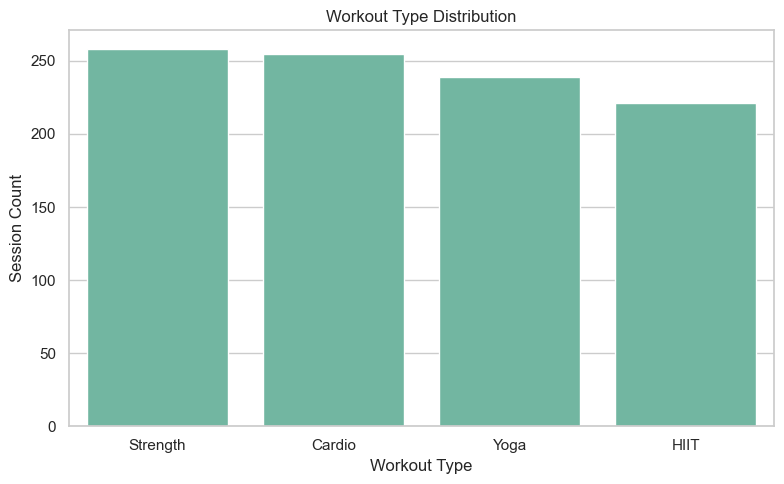

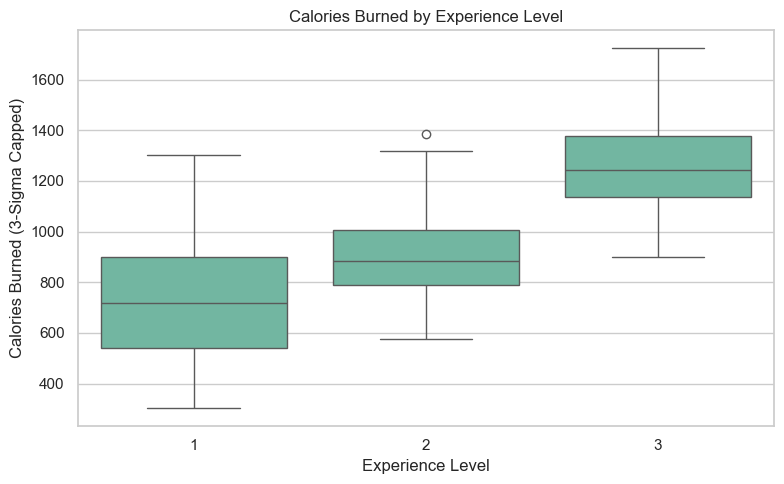

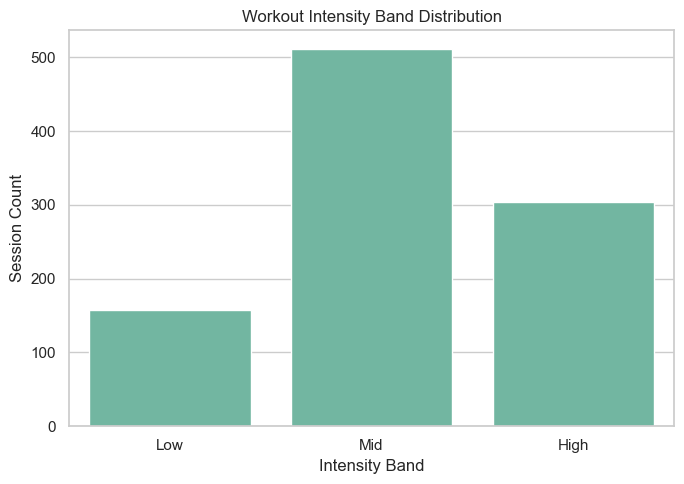

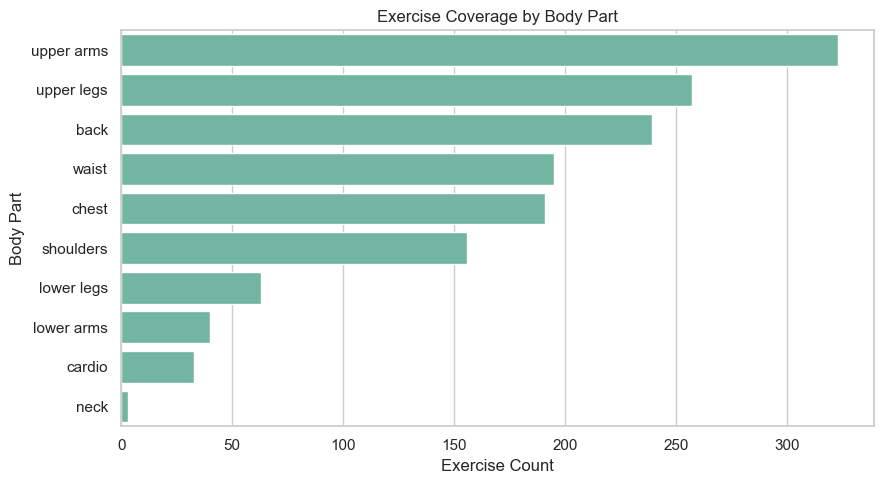

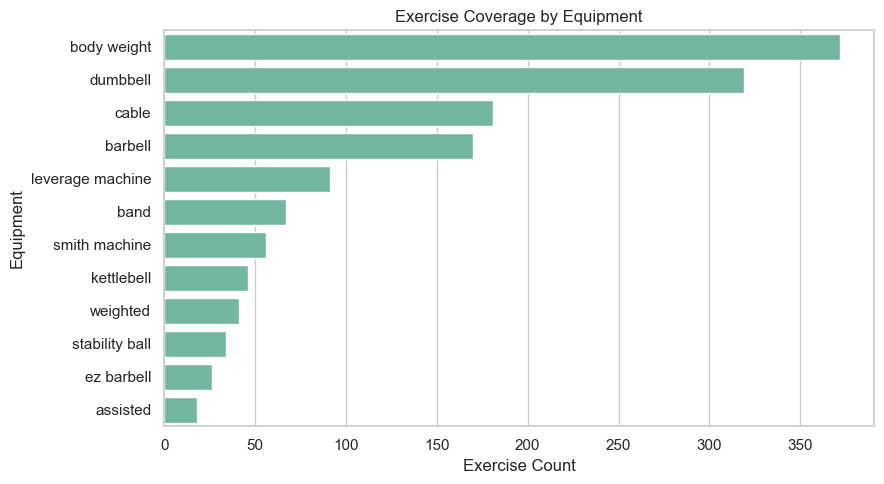

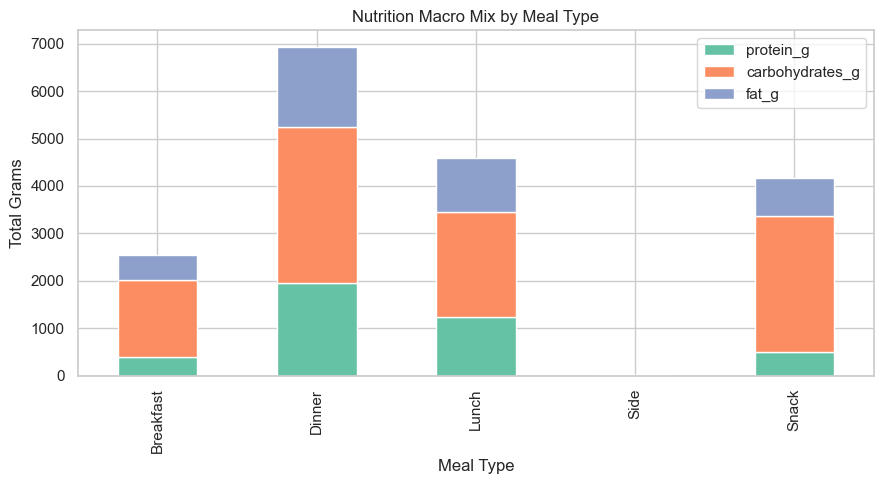

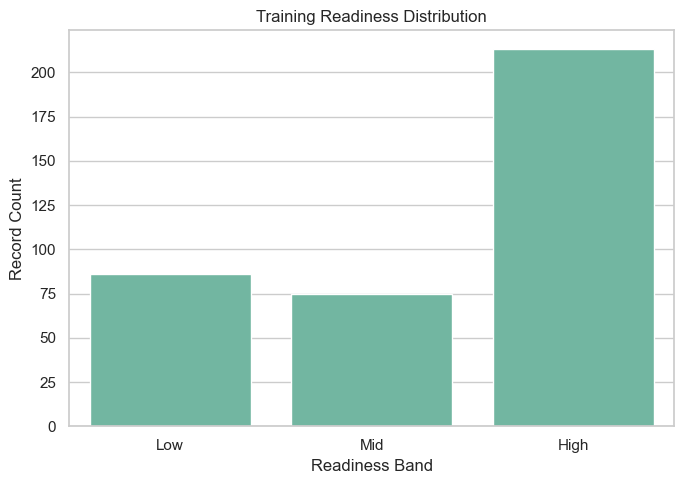

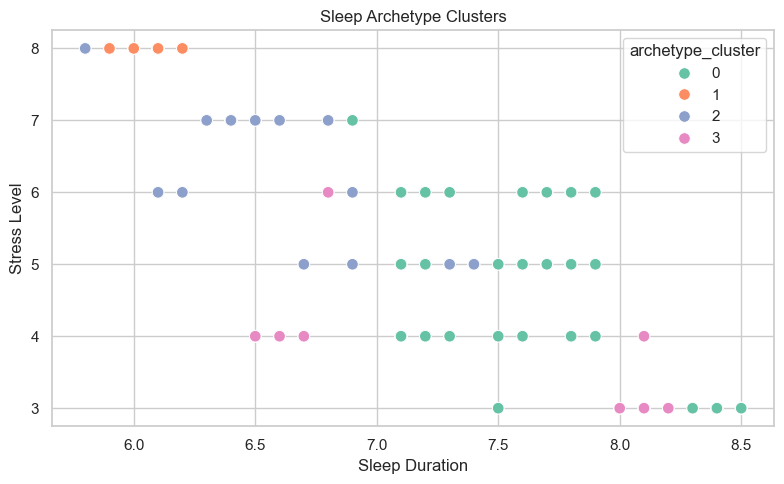

,figure_path
0,C:\Users\Waranon-021\Desktop\BIA Project\12597...
1,C:\Users\Waranon-021\Desktop\BIA Project\12597...
2,C:\Users\Waranon-021\Desktop\BIA Project\12597...
3,C:\Users\Waranon-021\Desktop\BIA Project\12597...
4,C:\Users\Waranon-021\Desktop\BIA Project\12597...
5,C:\Users\Waranon-021\Desktop\BIA Project\12597...
6,C:\Users\Waranon-021\Desktop\BIA Project\12597...
7,C:\Users\Waranon-021\Desktop\BIA Project\12597...


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\week1_figure_manifest.csv


In [14]:
figure_outputs = []                                                                                     # Saved PNG paths are collected for final validation.

plt.figure(figsize=(8, 5))                                                                              # A medium chart size works for dashboard cards and report pages.
sns.barplot(data=workout_type_distribution, x='workout_type', y='session_count')                        # Workout session counts are plotted by type.
plt.title('Workout Type Distribution')                                                                  # Chart title describes the EDA question.
plt.xlabel('Workout Type')                                                                              # x-axis label identifies the workout category.
plt.ylabel('Session Count')                                                                             # y-axis label identifies the count measure.
figure_outputs.append(save_current_plot('workout_type_distribution.png'))                               # The workout distribution plot is saved.

plt.figure(figsize=(8, 5))                                                                              # Boxplot size supports clear group comparison.
sns.boxplot(data=gym_clean, x='experience_level', y='calories_burned_clean')                            # Calories are compared across experience levels.
plt.title('Calories Burned by Experience Level')                                                        # Chart title links calories to experience.
plt.xlabel('Experience Level')                                                                          # x-axis label identifies user experience groups.
plt.ylabel('Calories Burned (3-Sigma Capped)')                                                          # y-axis label documents the cleaned calorie field.
figure_outputs.append(save_current_plot('calories_by_experience_level.png'))                            # The calorie pattern plot is saved.

plt.figure(figsize=(7, 5))                                                                              # Compact size works for three intensity classes.
sns.barplot(data=intensity_distribution, x='intensity_band', y='session_count', order=['Low', 'Mid', 'High']) # Intensity class counts are plotted in logical order.
plt.title('Workout Intensity Band Distribution')                                                        # Chart title names the derived target.
plt.xlabel('Intensity Band')                                                                            # x-axis label identifies class labels.
plt.ylabel('Session Count')                                                                             # y-axis label identifies the count measure.
figure_outputs.append(save_current_plot('intensity_band_distribution.png'))                             # The intensity target plot is saved.

plt.figure(figsize=(9, 5))                                                                              # Horizontal layout supports longer body part labels.
sns.barplot(data=body_part_coverage.head(12), x='exercise_count', y='body_part')                        # Top body part coverage is plotted.
plt.title('Exercise Coverage by Body Part')                                                             # Chart title describes catalogue coverage.
plt.xlabel('Exercise Count')                                                                            # x-axis label identifies exercise count.
plt.ylabel('Body Part')                                                                                 # y-axis label identifies body part.
figure_outputs.append(save_current_plot('exercise_coverage_by_body_part.png'))                          # The body part coverage plot is saved.

plt.figure(figsize=(9, 5))                                                                              # Horizontal layout supports longer equipment labels.
sns.barplot(data=equipment_coverage.head(12), x='exercise_count', y='equipment')                        # Top equipment coverage is plotted.
plt.title('Exercise Coverage by Equipment')                                                             # Chart title describes equipment coverage.
plt.xlabel('Exercise Count')                                                                            # x-axis label identifies exercise count.
plt.ylabel('Equipment')                                                                                 # y-axis label identifies equipment type.
figure_outputs.append(save_current_plot('exercise_coverage_by_equipment.png'))                          # The equipment coverage plot is saved.

macro_plot = macro_mix_summary.set_index('meal_type')[['protein_g', 'carbohydrates_g', 'fat_g']]        # Macro columns are selected for stacked plotting.
macro_plot.plot(kind='bar', stacked=True, figsize=(9, 5))                                               # Stacked bars show macro composition by meal type.
plt.title('Nutrition Macro Mix by Meal Type')                                                           # Chart title matches the Week 1 EDA requirement.
plt.xlabel('Meal Type')                                                                                 # x-axis label identifies meal category.
plt.ylabel('Total Grams')                                                                               # y-axis label identifies total macro grams.
figure_outputs.append(save_current_plot('nutrition_macro_mix_by_meal_type.png'))                        # The nutrition macro plot is saved.

plt.figure(figsize=(7, 5))                                                                              # Compact size works for three readiness bands.
sns.barplot(data=readiness_distribution, x='readiness_band', y='record_count', order=['Low', 'Mid', 'High']) # Readiness band counts are plotted in logical order.
plt.title('Training Readiness Distribution')                                                            # Chart title names the prescriptive readiness signal.
plt.xlabel('Readiness Band')                                                                            # x-axis label identifies readiness categories.
plt.ylabel('Record Count')                                                                              # y-axis label identifies sleep dataset records.
figure_outputs.append(save_current_plot('training_readiness_distribution.png'))                         # The readiness distribution plot is saved.

plt.figure(figsize=(8, 5))                                                                              # Scatterplot size supports cluster visualization.
sns.scatterplot(data=sleep_clean, x='sleep_duration', y='stress_level', hue='archetype_cluster', palette='Set2', s=70) # Clusters are shown using intuitive sleep and stress axes.
plt.title('Sleep Archetype Clusters')                                                                   # Chart title names the K-Means deliverable.
plt.xlabel('Sleep Duration')                                                                            # x-axis label identifies sleep amount.
plt.ylabel('Stress Level')                                                                              # y-axis label identifies stress score.
figure_outputs.append(save_current_plot('sleep_archetype_clusters.png'))                                # The cluster scatterplot is saved.

figure_manifest = pd.DataFrame({'figure_path': [str(path) for path in figure_outputs]})                 # Figure paths are stored in a manifest table.
display(figure_manifest)                                                                                # The figure manifest confirms all PNG outputs.
figure_manifest_output = export_dataframe(figure_manifest, 'week1_figure_manifest.csv')                 # Figure manifest is exported for final-product handoff.


## Cell 15: Final Data Contract Validation

This cell checks that cleaned datasets contain the fields needed by final product modules.

The contracts protect Week 2 and Week 3 work from silent data-shape changes.
        


In [15]:
required_columns = {                                                                                    # Each processed dataframe receives a minimum required-column contract.
    'sleep_clean': ['person_id', 'systolic_bp', 'diastolic_bp', 'readiness_score', 'readiness_band', 'archetype_cluster'], # Sleep fields needed for readiness and clustering.
    'gym_clean': ['bpm_response_ratio', 'intensity_band', 'calorie_burn_rate_kcal_per_hour', 'calories_burned_clean'], # Gym fields needed for Week 2 model training.
    'exercise_clean': ['exercise_id', 'name', 'body_parts', 'equipments', 'target_muscles', 'instruction_text'], # ExerciseDB fields needed for recommender and RAG.
    'nutrition_clean': ['food_item', 'meal_type', 'calories_kcal', 'protein_g', 'carbohydrates_g', 'fat_g', 'macro_total_g'], # Nutrition fields needed for macro dashboard.
}                                                                                                       # End of required-column contracts.

contract_frames = {                                                                                     # Cleaned dataframes are mapped to contract names.
    'sleep_clean': sleep_clean,                                                                         # Sleep dataframe with readiness and clusters.
    'gym_clean': gym_clean,                                                                             # Gym dataframe with intensity and calorie target fields.
    'exercise_clean': exercise_clean,                                                                   # ExerciseDB dataframe with parsed list fields.
    'nutrition_clean': nutrition_clean,                                                                 # Nutrition dataframe with cleaned macro fields.
}                                                                                                       # End of dataframe mapping.

contract_rows = []                                                                                      # Contract results are collected into a final table.
for dataset_name, columns in required_columns.items():                                                  # Each dataset contract is checked independently.
    dataframe = contract_frames[dataset_name]                                                           # The cleaned dataframe is selected.
    missing_columns = [column for column in columns if column not in dataframe.columns]                 # Missing required columns indicate a broken handoff.
    contract_rows.append({                                                                              # One contract result is added per dataset.
        'dataset': dataset_name,                                                                        # Dataset contract name.
        'required_column_count': len(columns),                                                          # Number of required fields.
        'missing_required_columns': missing_columns,                                                    # Missing required columns if any.
        'contract_passed': len(missing_columns) == 0,                                                   # Boolean contract result.
    })                                                                                                  # End of one contract row.

contract_table = pd.DataFrame(contract_rows)                                                            # Contract results become a readable dataframe.
display(contract_table)                                                                                 # The data contract table is displayed before final manifest creation.
assert contract_table['contract_passed'].all(), 'One or more Week 1 data contracts failed.'             # The notebook stops if any required handoff field is missing.

contract_output = export_dataframe(contract_table, 'week1_data_contract_validation.csv')                # Data contract validation is exported for final-product evidence.


,dataset,required_column_count,missing_required_columns,contract_passed
0,sleep_clean,6,[],True
1,gym_clean,4,[],True
2,exercise_clean,6,[],True
3,nutrition_clean,7,[],True


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\week1_data_contract_validation.csv


## Cell 16: Final TODO Checklist and Product Manifest

This cell produces the final Week 1 proof package.

The manifest records:

- Processed CSV files.
- Validation/proof files.
- Plot files.
- Summary JSON.
- TODO coverage.
- Final-product handoff destinations.
        


In [16]:
todo_checklist = pd.DataFrame([                                                                         # A visible checklist maps notebook outputs back to TODO.md.
    {'todo_line': 691, 'todo_item': 'Load and inspect all 4 CSVs', 'status': 'complete', 'evidence': 'week1_raw_inspection_summary.csv'}, # Raw inspection evidence.
    {'todo_line': 692, 'todo_item': 'Clean Sleep dataset', 'status': 'complete', 'evidence': 'sleep_cleaning_proof.csv'}, # Sleep cleaning evidence.
    {'todo_line': 693, 'todo_item': 'Clean Gym Members dataset', 'status': 'complete', 'evidence': 'gym_cleaned_intensity_calories.csv'}, # Gym cleaning evidence.
    {'todo_line': 694, 'todo_item': 'Clean ExerciseDB string-list fields', 'status': 'complete', 'evidence': 'exercisedb_parse_proof.csv'}, # ExerciseDB parsing evidence.
    {'todo_line': 695, 'todo_item': 'Clean Nutrition macro columns', 'status': 'complete', 'evidence': 'nutrition_numeric_validation.csv'}, # Nutrition cleaning evidence.
    {'todo_line': 696, 'todo_item': 'Derive Training Readiness rule', 'status': 'complete', 'evidence': 'readiness_component_summary.csv'}, # Readiness rule evidence.
    {'todo_line': 697, 'todo_item': 'Outlier check on Calories_Burned', 'status': 'complete', 'evidence': 'gym_calorie_outlier_proof.csv'}, # Outlier proof evidence.
    {'todo_line': 700, 'todo_item': 'K-Means clustering on Sleep dataset', 'status': 'complete', 'evidence': 'sleep_kmeans_silhouette_scores.csv + sleep_cluster_profile.csv'}, # K-Means evidence.
    {'todo_line': 701, 'todo_item': 'Cross-dataset EDA', 'status': 'complete', 'evidence': 'week1_dashboard_summary_tables.json'}, # Cross-dataset EDA evidence.
    {'todo_line': 702, 'todo_item': 'Save EDA plots as PNG', 'status': 'complete', 'evidence': 'week1_figure_manifest.csv'}, # Plot export evidence.
])                                                                                                      # End of final TODO checklist.

processed_outputs = [                                                                                   # All important Week 1 processed and proof files are listed for the manifest.
    raw_inspection_output, nutrition_repair_summary_output, sleep_cleaning_proof_output,                # Raw and cleaning proof outputs.
    readiness_component_output, sleep_readiness_output, gym_output, outlier_proof_output,               # Readiness and gym outputs.
    exercise_output, exercise_parse_proof_output, nutrition_output, nutrition_validation_output,        # Exercise and nutrition outputs.
    sleep_clusters_output, silhouette_output, cluster_profile_output, cluster_readiness_output,         # Clustering outputs.
    figure_manifest_output, contract_output,                                                            # Figure and contract outputs.
]                                                                                                       # End of processed output list.

processed_file_manifest = []                                                                            # Reloaded file metadata is collected for validation.
for output_path in processed_outputs:                                                                   # Each exported CSV is reloaded for proof of readability.
    exported_df = pd.read_csv(output_path)                                                              # Reloading checks the saved file rather than only memory state.
    processed_file_manifest.append({                                                                    # One metadata record is stored per exported file.
        'path': str(output_path),                                                                       # Full output path.
        'rows': int(exported_df.shape[0]),                                                              # Exported row count.
        'columns': int(exported_df.shape[1]),                                                           # Exported column count.
        'missing_values': int(exported_df.isna().sum().sum()),                                          # Total missing values after export.
    })                                                                                                  # End of one output metadata record.

todo_checklist_output = export_dataframe(todo_checklist, 'week1_todo_completion_checklist.csv')         # TODO checklist is exported.

final_manifest = {                                                                                      # The final manifest becomes the top-level Week 1 handoff document.
    'project': 'Smart Workout DSS/BIS',                                                                 # Project name.
    'scope': 'Week 1 Earth and Non data foundation complete package',                                   # Manifest scope.
    'project_root': str(PROJECT_ROOT),                                                                  # Project root used by the notebook.
    'processed_dir': str(PROCESSED_DIR),                                                                # Processed output folder.
    'figures_dir': str(FIGURES_DIR),                                                                    # Figure output folder.
    'summary_tables_path': str(summary_tables_path),                                                    # Dashboard summary JSON path.
    'selected_sleep_cluster_k': selected_k,                                                             # Selected K-Means cluster count.
    'processed_files': processed_file_manifest,                                                         # All processed/proof CSV metadata.
    'figure_files': [str(path) for path in figure_outputs],                                             # All saved PNG figure paths.
    'todo_checklist': todo_checklist.to_dict(orient='records'),                                         # TODO completion records.
    'final_product_handoff': {                                                                          # Downstream usage map.
        'week2_ml': ['gym_cleaned_intensity_calories.csv', 'sleep_cleaned_readiness_clusters.csv'],     # Files for Week 2 model training.
        'week3_dashboard': ['week1_dashboard_summary_tables.json', 'docs/figures/week1/*.png'],         # Files for Week 3 dashboard views.
        'recommender_rag': ['exercisedb_cleaned_catalog.csv'],                                          # Exercise catalogue for recommender and RAG.
        'report_evidence': ['week1_manifest_complete.json', 'week1_todo_completion_checklist.csv'],     # Files for report evidence.
    },                                                                                                  # End of downstream usage map.
}                                                                                                       # End of final manifest dictionary.

final_manifest_path = PROCESSED_DIR / 'week1_manifest_complete.json'                                    # The final manifest is saved beside processed outputs.
final_manifest_path.write_text(json.dumps(final_manifest, indent=2), encoding='utf-8')                  # Readable JSON supports manual and programmatic review.

display(todo_checklist)                                                                                 # Final TODO checklist is displayed.
display(pd.DataFrame(processed_file_manifest))                                                          # Processed file manifest is displayed.
print('Final manifest saved:', final_manifest_path)                                                     # The final manifest path is printed.
print('Week 1 complete package is ready for final-product handoff.')                                    # Completion message confirms the notebook reached the end.


Saved processed file: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\week1_todo_completion_checklist.csv


,todo_line,todo_item,status,evidence
0,691,Load and inspect all 4 CSVs,complete,week1_raw_inspection_summary.csv
1,692,Clean Sleep dataset,complete,sleep_cleaning_proof.csv
2,693,Clean Gym Members dataset,complete,gym_cleaned_intensity_calories.csv
3,694,Clean ExerciseDB string-list fields,complete,exercisedb_parse_proof.csv
4,695,Clean Nutrition macro columns,complete,nutrition_numeric_validation.csv
5,696,Derive Training Readiness rule,complete,readiness_component_summary.csv
6,697,Outlier check on Calories_Burned,complete,gym_calorie_outlier_proof.csv
7,700,K-Means clustering on Sleep dataset,complete,sleep_kmeans_silhouette_scores.csv + sleep_clu...
8,701,Cross-dataset EDA,complete,week1_dashboard_summary_tables.json
9,702,Save EDA plots as PNG,complete,week1_figure_manifest.csv


,path,rows,columns,missing_values
0,C:\Users\Waranon-021\Desktop\BIA Project\12597...,4,6,0
1,C:\Users\Waranon-021\Desktop\BIA Project\12597...,651,5,0
2,C:\Users\Waranon-021\Desktop\BIA Project\12597...,4,2,0
3,C:\Users\Waranon-021\Desktop\BIA Project\12597...,3,6,0
4,C:\Users\Waranon-021\Desktop\BIA Project\12597...,374,24,219
5,C:\Users\Waranon-021\Desktop\BIA Project\12597...,973,21,0
6,C:\Users\Waranon-021\Desktop\BIA Project\12597...,1,7,0
7,C:\Users\Waranon-021\Desktop\BIA Project\12597...,1500,13,0
8,C:\Users\Waranon-021\Desktop\BIA Project\12597...,8,7,0
9,C:\Users\Waranon-021\Desktop\BIA Project\12597...,651,18,0


Final manifest saved: C:\Users\Waranon-021\Desktop\BIA Project\125970-125934-125843-BIA-main\data\processed\week1_manifest_complete.json
Week 1 complete package is ready for final-product handoff.


## Final Product Handoff Summary

After running this notebook from the project root, the following folders should contain the Week 1 complete package:

```text
data/processed/
  week1_raw_inspection_summary.csv
  sleep_cleaning_proof.csv
  sleep_cleaned_readiness.csv
  sleep_cleaned_readiness_clusters.csv
  gym_cleaned_intensity_calories.csv
  gym_calorie_outlier_proof.csv
  exercisedb_cleaned_catalog.csv
  exercisedb_parse_proof.csv
  nutrition_cleaned_macros.csv
  nutrition_csv_repair_log.csv
  nutrition_numeric_validation.csv
  sleep_kmeans_silhouette_scores.csv
  sleep_cluster_profile.csv
  sleep_cluster_readiness_mix.csv
  week1_dashboard_summary_tables.json
  week1_figure_manifest.csv
  week1_data_contract_validation.csv
  week1_todo_completion_checklist.csv
  week1_manifest_complete.json

docs/figures/week1/
  workout_type_distribution.png
  calories_by_experience_level.png
  intensity_band_distribution.png
  exercise_coverage_by_body_part.png
  exercise_coverage_by_equipment.png
  nutrition_macro_mix_by_meal_type.png
  training_readiness_distribution.png
  sleep_archetype_clusters.png
```

This output is enough for the Week 1 Earth and Non scope: data cleaning, validation proof, descriptive analytics, K-Means profiles, EDA assets, and final-product handoff.
        
